# FT-Transformers d'estimation de valeur foncière actuelle

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from collections import defaultdict
import fastparquet as fp
import joblib
import copy
import matplotlib.pyplot as plt
import re
import os

## 1. Chargement du fichier parquet

In [3]:
df = fp.ParquetFile("./data/dvf_merged_since2014_final.parquet").to_pandas()

FileNotFoundError: ./data/dvf_merged_since2014_final.parquet

## 2. Pre-processing

### 2.1. Sélection features et traitements avant split

In [3]:
# Gestion des dates et filtrage des valeurs aberrantes
df["date_mutation"] = pd.to_datetime(df["date_mutation"], errors="coerce")
df = df[df["valeur_fonciere"] < 1_000_000]
df = df.sort_values("date_mutation")
df["target"] = np.log(df["valeur_fonciere"])

# Sélection des features utiles
CATEGORICAL_COLS = ['type_local', 'code_postal', 'code_departement', 'code_voie']
features = [
    'date_mutation', 'type_local', 'surface_reelle_bati',
    'nb_pieces_principales', 'code_postal', 'code_departement', 'code_voie',
    'nombre_de_lots', 'surface_m2', 'source_year', 'code_insee', 'lat', 'lon',
    'distance_centre_ville', 'densite_commune', 'altitude_moyenne_commune',
    'population_commune','prix_m2_median_cp','prix_m2_mean_cp','prix_m2_std_cp',
    'surface_m2_median_cp','nb_pieces_mean_cp','transactions_cp','prix_m2_median_cp_last_12m',
    'transactions_cp_last_12m','densite_x_population','densite_population_ratio',
    'densite_altitude_ratio','attractivite_simple','distance_x_densite'
]
X = df[features].copy()
y = df["target"].copy()

# Traitement des NaNs/Cohérence des colonnes numériques (avant le split)
X['nombre_de_lots'] = pd.to_numeric(X['nombre_de_lots'], errors='coerce').fillna(1)
X['code_insee'] = pd.to_numeric(X['code_insee'], errors='coerce').fillna(0)
X['nb_pieces_principales'] = pd.to_numeric(X['nb_pieces_principales'], errors='coerce').fillna(1)

# Traitement de la date
X['month_mutation'] = X['date_mutation'].dt.month
X = X.drop(columns=['date_mutation'])
CATEGORICAL_COLS.append('month_mutation')

NUMERICAL_COLS = [col for col in X.columns if col not in CATEGORICAL_COLS]

N_NUM = len(NUMERICAL_COLS)
N_CAT = len(CATEGORICAL_COLS)
N_FEATURES = N_NUM + N_CAT

### 2.2. Split train/test basé sur la date

In [4]:
# Split train/test basé sur la date
train_mask = df["date_mutation"] < "2023-11-01"
X_train, X_test = X[train_mask].copy(), X[~train_mask].copy()
y_train, y_test = y[train_mask].copy(), y[~train_mask].copy()

print(f"Taille train : {len(X_train)}")
print(f"Taille test  : {len(X_test)}")

Taille train : 11519249
Taille test  : 1583000


### 2.3. Encodage catégoriel et calcul de CAT_DIMS

In [5]:
# Encodage Catégoriel et Calcul de CAT_DIMS
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train[CATEGORICAL_COLS] = encoder.fit_transform(X_train[CATEGORICAL_COLS])
X_test[CATEGORICAL_COLS] = encoder.transform(X_test[CATEGORICAL_COLS])

# Fonction de remappage: mappage du -1 (unknown) vers l'index 0, et décalage des autres de +1
def remap_categorical_indices(X_cat):
    X_cat = X_cat.astype(int)
    unknown_mask = (X_cat == -1)
    X_cat[unknown_mask] = 0        # L'indice 0 est réservé pour 'unknown'
    X_cat[~unknown_mask] += 1      # Décalage des catégories connues (originales >= 0)
    return X_cat

X_train[CATEGORICAL_COLS] = remap_categorical_indices(X_train[CATEGORICAL_COLS].values)
X_test[CATEGORICAL_COLS] = remap_categorical_indices(X_test[CATEGORICAL_COLS].values)

# Calcul de CAT_DIMS (Taille de l'Embedding = max(index) + 1 sur le TRAIN set)
CAT_DIMS = {
    col: X_train[col].max() + 1
    for col in CATEGORICAL_COLS
}

### 2.4. Imputation des NaN numériques

21% des entrées ne sont pas complètes du fait de la jointure des code_voies des DVF avec les données nationales des communes qui a créée des features NaN.

En imputant ces NaN avec les médianes par code_insee, on obtient un résultat très proche de la réalité.

In [6]:
COLUMNS_TO_IMPUTE = [
    'lat', 'lon', 'distance_centre_ville', 'densite_commune', 
    'altitude_moyenne_commune', 'population_commune', 'densite_x_population', 
    'densite_population_ratio', 'densite_altitude_ratio', 
    'attractivite_simple', 'distance_x_densite'
]

imputation_map_train = X_train.groupby('code_insee')[COLUMNS_TO_IMPUTE].transform('median')
imputation_map_test = X_test.groupby('code_insee')[COLUMNS_TO_IMPUTE].transform('median')

# Remplir les NaNs restants dans X_train et X_test
for col in COLUMNS_TO_IMPUTE:
    # Remplir les NaNs de X_train avec les médianes par groupe de X_train
    X_train[col] = X_train[col].fillna(imputation_map_train[col])
    
    # Remplir les NaNs de X_test avec les médianes par groupe de X_test
    X_test[col] = X_test[col].fillna(imputation_map_test[col])

# Calculer la médiane globale de chaque colonne sur X_train (après la première imputation)
global_median = X_train[COLUMNS_TO_IMPUTE].median()

# Imputer les NaNs restants dans X_train et X_test avec la médiane globale de X_train
X_train[COLUMNS_TO_IMPUTE] = X_train[COLUMNS_TO_IMPUTE].fillna(global_median)
X_test[COLUMNS_TO_IMPUTE] = X_test[COLUMNS_TO_IMPUTE].fillna(global_median)

# Vérification Finale
print(f"NaNs restants dans X_train après imputation: {X_train[COLUMNS_TO_IMPUTE].isnull().sum().max()}")
print(f"NaNs restants dans X_test après imputation: {X_test[COLUMNS_TO_IMPUTE].isnull().sum().max()}")

NaNs restants dans X_train après imputation: 0
NaNs restants dans X_test après imputation: 0


### 2.5. Standardisation des Caractéristiques Numériques et de la Cible

In [ ]:
# Scaling des Features Numériques (StandardScaler: recommandé pour DL)
num_scaler = StandardScaler()
X_train[NUMERICAL_COLS] = num_scaler.fit_transform(X_train[NUMERICAL_COLS])
X_test[NUMERICAL_COLS] = num_scaler.transform(X_test[NUMERICAL_COLS])

joblib.dump(num_scaler, './models/num_scaler.pkl')
print("Scaler numérique sauvegardé sous ./models/num_scaler.pkl")

# Scaling de la Cible (Log-Target: pour améliorer la stabilité de l'entraînement)
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

print("\nTarget Scaler Stats (pour dé-normalisation):")
print(f"Log Mean: {target_scaler.mean_[0]:.4f}")
print(f"Log Std: {target_scaler.scale_[0]:.4f}")


Target Scaler Stats (pour dé-normalisation):
Log Mean: 12.0120
Log Std: 0.7775


## 3. Hyperparamètres du FT-Transformer

In [ ]:
D_EMB = 128  # Feature embedding size 
N_HEADS = 8
N_LAYERS = 3 
FFN_FACTOR = 4/3
ATTENTION_DROPOUT = 0.2
FFN_DROPOUT = 0.1
RESIDUAL_DROPOUT = 0.0

LR = 1e-4
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 256
N_EPOCHS = 50
PATIENCE = 10 # Pour l'Early Stopping

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Convertion des données en Tenseurs PyTorch
X_train_num_all = torch.tensor(X_train[NUMERICAL_COLS].values, dtype=torch.float32)
X_train_cat_all = torch.tensor(X_train[CATEGORICAL_COLS].values, dtype=torch.long)
y_train_tensor_all = torch.tensor(y_train_scaled, dtype=torch.float32).unsqueeze(1)

X_test_num = torch.tensor(X_test[NUMERICAL_COLS].values, dtype=torch.float32)
X_test_cat = torch.tensor(X_test[CATEGORICAL_COLS].values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).unsqueeze(1)

# Création des TensorDatasets
train_data = TensorDataset(X_train_num_all, X_train_cat_all, y_train_tensor_all)
test_data = TensorDataset(X_test_num, X_test_cat, y_test_tensor)

# Split du jeu de TRAIN en TRAIN et VALIDATION (80/20)
train_len = int(0.8 * len(train_data))
val_len = len(train_data) - train_len
train_subset, val_subset = random_split(train_data, [train_len, val_len])

# Création des DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print("\nCAT_DIMS (taille des embeddings):")
print(CAT_DIMS)

Using device: cuda

CAT_DIMS (taille des embeddings):
{'type_local': 5, 'code_postal': 5869, 'code_departement': 98, 'code_voie': 16592, 'month_mutation': 13}


## 4. Composants du FT-Transformer

In [9]:
# La fonction d'activation ReGLU (ou ReLU si ReGLU n'est pas implémentée)
# ReGLU = Max(0, xW + b) * V [cite: 502, 405]
class ReGLU(nn.Module):
    def forward(self, x):
        # Assumant que l'entrée est le double de la taille cachée (pour la séparation W et V)
        x_linear, x_gated = x.chunk(2, dim=-1)
        return x_linear * torch.relu(x_gated)

### 4.1. Feature Tokenizer (FT)

In [10]:
class FeatureTokenizer(nn.Module):
    def __init__(self, n_num, cat_dims, d_emb):
        super().__init__()
        self.n_num = n_num
        self.n_cat = len(cat_dims)
        self.cat_dims = cat_dims
        self.d_emb = d_emb

        # Tokenizer pour les caractéristiques numériques: x_j * W_j + b_j
        self.num_weights = nn.Parameter(torch.Tensor(n_num, d_emb))
        self.num_biases = nn.Parameter(torch.Tensor(n_num, d_emb))
        nn.init.xavier_uniform_(self.num_weights)
        nn.init.zeros_(self.num_biases)

        # Tokenizer pour les caractéristiques catégorielles (Tables de lookup + Biases)
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(dim, d_emb) for dim in cat_dims
        ])
        self.cat_biases = nn.ParameterList([
            nn.Parameter(torch.Tensor(d_emb)) for _ in cat_dims
        ])
        for emb in self.cat_embeddings:
            nn.init.xavier_uniform_(emb.weight)
        for bias in self.cat_biases:
            nn.init.zeros_(bias)

        # Token CLS
        self.cls_token = nn.Parameter(torch.Tensor(1, 1, d_emb))
        nn.init.normal_(self.cls_token)

    def forward(self, x_num, x_cat):
        # Tokens Numériques: (Batch, N_NUM, D_EMB)
        x_num = x_num.unsqueeze(2) # (B, N_NUM, 1)
        # Multiplication élément par élément (B, N_NUM, D_EMB)
        num_tokens = x_num * self.num_weights.unsqueeze(0) + self.num_biases.unsqueeze(0)

        # Tokens Catégoriels: (Batch, N_CAT, D_EMB)
        cat_tokens = []
        for i, (emb, bias) in enumerate(zip(self.cat_embeddings, self.cat_biases)):
            # x_cat[:, i] est l'indice de la catégorie (B,)
            token = emb(x_cat[:, i]) + bias # (B, D_EMB)
            cat_tokens.append(token.unsqueeze(1))

        # Concaténation des tokens: (Batch, N_NUM + N_CAT, D_EMB)
        feature_tokens = torch.cat([num_tokens] + cat_tokens, dim=1)

        # Ajout du token CLS: (Batch, N_FEATURES + 1, D_EMB)
        cls_token = self.cls_token.expand(feature_tokens.shape[0], -1, -1)
        full_sequence = torch.cat([cls_token, feature_tokens], dim=1)

        return full_sequence

### 4.2. Transformer Block (PreNorm Residual)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d_emb, n_heads, ffn_factor, attn_dropout, ffn_dropout, resid_dropout):
        super().__init__()

        # Multi-Head Self-Attention (MHSA)
        self.norm_attn = nn.LayerNorm(d_emb)
        self.attn = nn.MultiheadAttention(d_emb, n_heads, dropout=attn_dropout, batch_first=True)
        self.dropout_attn = nn.Dropout(resid_dropout)

        # Feed Forward Network (FFN)
        self.norm_ffn = nn.LayerNorm(d_emb)
        d_inner = int(d_emb * ffn_factor)
        self.ffn = nn.Sequential(
            nn.Linear(d_emb, d_inner * 2),
            ReGLU(),
            nn.Dropout(ffn_dropout),
            nn.Linear(d_inner, d_emb),
        )
        self.dropout_ffn = nn.Dropout(resid_dropout)

    def forward(self, x):
        # MHSA avec PreNorm (Résiduel 1)
        norm_x = self.norm_attn(x)
        attn_output, _ = self.attn(norm_x, norm_x, norm_x)
        x = x + self.dropout_attn(attn_output)

        # FFN avec PreNorm (Résiduel 2)
        norm_x = self.norm_ffn(x)
        ffn_output = self.ffn(norm_x)
        x = x + self.dropout_ffn(ffn_output)

        return x

### 4.3. Modèle FT-Transformer final

In [12]:
class FTTransformer(nn.Module):
    def __init__(self, n_num, cat_dims, d_emb, n_layers, n_heads, ffn_factor, attn_dropout, ffn_dropout, resid_dropout):
        super().__init__()
        self.feature_tokenizer = FeatureTokenizer(n_num, cat_dims, d_emb)

        # Transformer Backbone
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_emb, n_heads, ffn_factor, attn_dropout, ffn_dropout, resid_dropout)
            for _ in range(n_layers)
        ])

        # Tête de Prédiction
        # Pas de ReLu afin de garder les valeurs négatives avant la dé-normalisation
        self.prediction_head = nn.Sequential(
            nn.LayerNorm(d_emb), 
            nn.Linear(d_emb, 1) 
        )

    def forward(self, x_num, x_cat):
        # 1. Feature Tokenizer
        x = self.feature_tokenizer(x_num, x_cat)

        # 2. Transformer Blocks
        for block in self.transformer_blocks:
            x = block(x)

        # 3. Prediction Head (utilise uniquement le CLS token: x[:, 0])
        cls_token_output = x[:, 0]
        prediction = self.prediction_head(cls_token_output)

        return prediction

## 5. Entrainement du modèle

In [ ]:
model = FTTransformer(
    n_num=N_NUM,
    cat_dims=list(CAT_DIMS.values()),
    d_emb=D_EMB,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    ffn_factor=FFN_FACTOR,
    attn_dropout=ATTENTION_DROPOUT, 
    ffn_dropout=FFN_DROPOUT,
    resid_dropout=RESIDUAL_DROPOUT
).to(DEVICE)

no_decay = ['bias', 'LayerNorm.weight', 'feature_tokenizer.num_biases', 'feature_tokenizer.cat_biases', 'cls_token']
optimizer_grouped_parameters = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]

optimizer = optim.AdamW(optimizer_grouped_parameters, lr=LR)
criterion = nn.MSELoss() # Régression sur log(prix)

# Boucle d'entraînement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

print("\n--- Entraînement du FT-Transformer ---")
for epoch in range(N_EPOCHS):
    if early_stop:
        print(f"Early stopping déclenché à l'époque {epoch}.")
        break

    model.train()
    total_loss = 0
    for x_num, x_cat, y in train_loader:
        x_num, x_cat, y = x_num.to(DEVICE), x_cat.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        output = model(x_num, x_cat)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # PHASE de VALIDATION 
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_num, x_cat, y in val_loader:
            x_num, x_cat, y = x_num.to(DEVICE), x_cat.to(DEVICE), y.to(DEVICE)
            output = model(x_num, x_cat)
            loss = criterion(output, y)
            val_loss += loss.item() * len(y)
    
    avg_val_loss = val_loss / len(val_subset)

    print(f"Epoch {epoch+1}/{N_EPOCHS} | Train MSE: {avg_train_loss:.6f} | Val MSE: {avg_val_loss:.6f}")
    
    # EARLY STOPPING et Sauvegarde des Meilleurs Poids
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Sauvegarder une copie profonde des poids
        best_model_weights = copy.deepcopy(model.state_dict())
        print("    -> Val Loss améliorée. Poids du modèle sauvegardés.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            early_stop = True

# Charger les meilleurs poids sauvegardés avant l'évaluation finale
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print(f"Modèle restauré à la meilleure époque (Val MSE: {best_val_loss:.6f}).")
    torch.save(model.state_dict(), 'ft_transformer_best_model_weights.pt')
    print("\nModèle enregistré sur le disque : ft_transformer_best_model_weights.pt")
else:
    print("Attention: Early stopping n'a pas trouvé de meilleurs poids que l'initialisation.")


--- Entraînement du FT-Transformer ---


## 6. Inférence

In [ ]:
print("\n--- Prédiction sur l'ensemble de Test ---")
model.eval()
test_predictions = []
test_targets = []

with torch.no_grad():
    for x_num, x_cat, y in test_loader:
        x_num, x_cat = x_num.to(DEVICE), x_cat.to(DEVICE)
        output = model(x_num, x_cat)
        test_predictions.append(output.cpu().numpy())
        test_targets.append(y.cpu().numpy())

y_pred_log = np.concatenate(test_predictions).flatten()
y_true_log = np.concatenate(test_targets).flatten()

# Reconversion de log(prix) en prix (€)
# Dé-normalisation: Y_log_raw = Y_log * std_log + mean_log
y_pred_log_raw = (y_pred_log * target_scaler.scale_[0]) + target_scaler.mean_[0]
y_true_log_raw = (y_true_log * target_scaler.scale_[0]) + target_scaler.mean_[0]

y_pred = np.exp(y_pred_log_raw)
y_true = np.exp(y_true_log_raw)

## 7. Evaluation

In [ ]:
def evaluate_by_price_range(y_true_eur, y_pred_eur):
    """Calcule les métriques MAE et RMSE par tranche de prix."""
    results = {}
    total_mae = mean_absolute_error(y_true_eur, y_pred_eur)
    total_rmse = np.sqrt(mean_squared_error(y_true_eur, y_pred_eur))
    total_r2 = r2_score(y_true_eur, y_pred_eur)

    results['Global'] = {'MAE': total_mae, 'RMSE': total_rmse, 'R2': total_r2, 'Proportion': 1.0}

    # Définition des tranches (en €)
    ranges = [
        (0, 200000, "0-200k€"),
        (200000, 500000, "200k-500k€"),
        (500000, 1000000, "500k-1M€"),
    ]

    n_total = len(y_true_eur)

    for min_p, max_p, label in ranges:
        mask = (y_true_eur >= min_p) & (y_true_eur < max_p)
        y_true_range = y_true_eur[mask]
        y_pred_range = y_pred_eur[mask]

        if len(y_true_range) > 0:
            mae = mean_absolute_error(y_true_range, y_pred_range)
            rmse = np.sqrt(mean_squared_error(y_true_range, y_pred_range))
            proportion = len(y_true_range) / n_total
            results[label] = {'MAE': mae, 'RMSE': rmse, 'Proportion': proportion}
        else:
            results[label] = {'MAE': 0, 'RMSE': 0, 'Proportion': 0}

    return results

# Calcul et affichage des résultats
evaluation_results = evaluate_by_price_range(y_true, y_pred)

print("\n" + "="*50)
print("--- Évaluation Finale du FT-Transformer ---")
print("="*50)

# Affichage du format demandé
print(f"--- Performance Globale du modèle ---")
global_res = evaluation_results['Global']
print(f"    MAE  : {global_res['MAE']:,.0f} €")
print(f"    RMSE : {global_res['RMSE']:,.0f} €")
print(f"    R²   : {global_res['R2']:.4f}")

print("\n" + "--- Évaluation par Tranche de Prix (sur Target y_true) ---")
for label in ["0-200k€", "200k-500k€", "500k-1M€"]:
    res = evaluation_results[label]
    if res['Proportion'] > 0:
        print(f"--- {label} (proportion : {res['Proportion']*100:.2f}%) ---")
        print(f"    MAE  : {res['MAE']:,.0f} €")
        print(f"    RMSE : {res['RMSE']:,.0f} €")
    else:
        print(f"--- {label} (proportion : {res['Proportion']*100:.2f}%) --- (AUCUNE DONNÉE DANS CETTE TRANCHE)")

## 8. Sortie de l'exécution

Le modèle prenant environ 14h pour effectuer 50 epochs, le notebook à été converti en script python puis lancé dans un screen sur les serveurs de calcul afin de pouvoir se détacher du docker.

La sortie de l'exécution est : 

In [2]:
with open('models_output/FT-Transformer_output.log') as f :
    print(f.read())

Taille train : 11519249
Taille test  : 1583000
NaNs restants dans X_train après imputation: 0
NaNs restants dans X_test après imputation: 0

Target Scaler Stats (pour dé-normalisation):
Log Mean: 12.0120
Log Std: 0.7775
Using device: cuda

CAT_DIMS (taille des embeddings):
{'type_local': 5, 'code_postal': 5869, 'code_departement': 98, 'code_voie': 16592, 'month_mutation': 13}

--- Entraînement du FT-Transformer ---
Epoch 1/50 | Train MSE: 0.439883 | Val MSE: 0.418259
    -> Val Loss améliorée. Poids du modèle sauvegardés.
Epoch 2/50 | Train MSE: 0.410266 | Val MSE: 0.407853
    -> Val Loss améliorée. Poids du modèle sauvegardés.
Epoch 3/50 | Train MSE: 0.396406 | Val MSE: 0.399666
    -> Val Loss améliorée. Poids du modèle sauvegardés.
Epoch 4/50 | Train MSE: 0.386320 | Val MSE: 0.395041
    -> Val Loss améliorée. Poids du modèle sauvegardés.
Epoch 5/50 | Train MSE: 0.378220 | Val MSE: 0.390449
    -> Val Loss améliorée. Poids du modèle sauvegardés.
Epoch 6/50 | Train MSE: 0.371594 | V

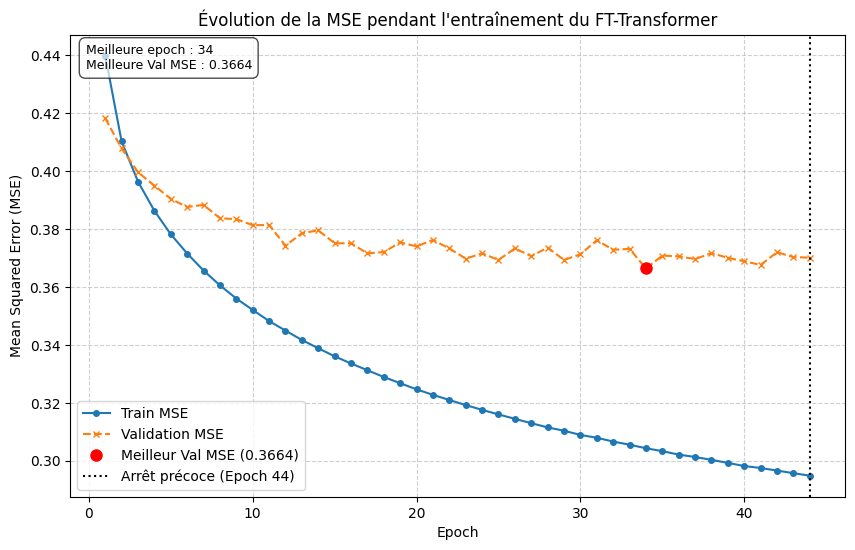

In [6]:
file_path = 'models_output/FT-Transformer_output.log'

if not os.path.exists(file_path):
    print(f"Erreur : Le fichier spécifié est introuvable à l'adresse : {file_path}")
else:
    epochs = []
    train_mse = []
    val_mse = []

    try:
        with open(file_path, 'r') as f:
            log_content = f.read()
            
            # Expression régulière pour extraire les valeurs (Epoch, Train MSE, Val MSE)
            pattern = re.compile(r'Epoch (\d+)/50 \| Train MSE: (\d+\.\d+) \| Val MSE: (\d+\.\d+)')
            matches = pattern.findall(log_content)
            
            for match in matches:
                epoch, train, val = match
                epochs.append(int(epoch))
                train_mse.append(float(train))
                val_mse.append(float(val))
                
    except Exception as e:
        print(f"Une erreur s'est produite lors de la lecture ou de l'analyse du fichier : {e}")


    if epochs:
        plt.figure(figsize=(10, 6))

        plt.plot(epochs, train_mse, label='Train MSE', marker='o', markersize=4, linestyle='-')
        plt.plot(epochs, val_mse, label='Validation MSE', marker='x', markersize=5, linestyle='--')

        # Trouver le meilleur MSE de validation
        best_val_mse = min(val_mse)
        best_epoch = epochs[val_mse.index(best_val_mse)]
        plt.plot(best_epoch, best_val_mse, 'ro', label=f'Meilleur Val MSE ({best_val_mse:.4f})', markersize=8)
        
        # Ajouter une ligne verticale pour l'arrêt précoce (si Early stopping est mentionné dans le log)
        early_stopping_match = re.search(r'Early stopping déclenché à l\'époque (\d+)', log_content)
        if early_stopping_match:
            early_stop_epoch = int(early_stopping_match.group(1))
            plt.axvline(x=early_stop_epoch, color='k', linestyle=':', label=f'Arrêt précoce (Epoch {early_stop_epoch})')

        # Étiquettes et titre
        plt.title('Évolution de la MSE pendant l\'entraînement du FT-Transformer')
        plt.xlabel('Epoch')
        plt.ylabel('Mean Squared Error (MSE)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.text(0.02, 0.98, 
            f"Meilleure epoch : {best_epoch}\nMeilleure Val MSE : {best_val_mse:.4f}", 
            transform=plt.gca().transAxes, 
            fontsize=9, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7))
        plt.show()

    else:
        print("Aucune donnée d'entraînement/validation n'a pu être extraite du fichier.")